<H1>NetFlix Churn Prediction</h2>

<h3>Importing libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\documents\codeit\netflix_churn\netflix_users.csv")
df.head(2)

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05


<h3>Check data</h3>

In [3]:
df.shape

(25000, 8)

In [4]:
df.describe()

,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


In [6]:
df.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

<h3>removing unwanted columns</h3>

In [7]:
df=df.drop(columns=['User_ID','Name'])

In [8]:
df.head(2)

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,18,France,Premium,80.26,Drama,2024-05-12
1,23,USA,Premium,321.75,Sci-Fi,2025-02-05


<h3>create churn column</h3>

In [9]:
df['Last_Login']= pd.to_datetime(df['Last_Login'])


In [10]:
df['Days_Since_Login'] = (pd.Timestamp.today()-df['Last_Login']).dt.days

In [11]:
df.head(2)

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Days_Since_Login
0,18,France,Premium,80.26,Drama,2024-05-12,671
1,23,USA,Premium,321.75,Sci-Fi,2025-02-05,402


In [12]:
# define churn
df['Churn'] = ((df['Days_Since_Login'] > 180) & (df['Watch_Time_Hours'] < 300) ).astype(int)

In [13]:
df.head(2)

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Days_Since_Login,Churn
0,18,France,Premium,80.26,Drama,2024-05-12,671,1
1,23,USA,Premium,321.75,Sci-Fi,2025-02-05,402,0


In [14]:
df=df.drop(columns=['Last_Login','Days_Since_Login'])

<h2>Exploratory Data Analysis</h2>

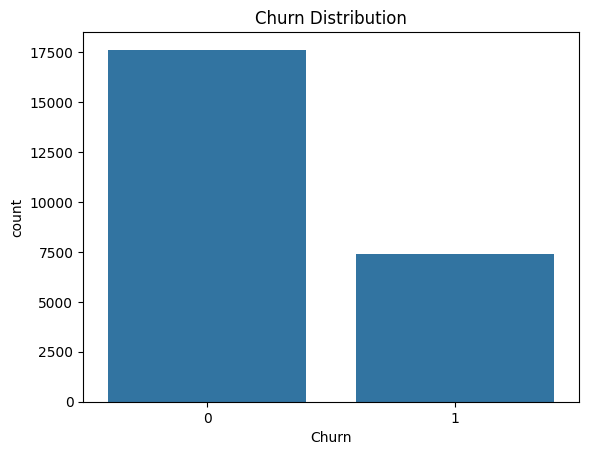

In [15]:
sns.countplot(x='Churn',data=df)
plt.title("Churn Distribution")
plt.show()

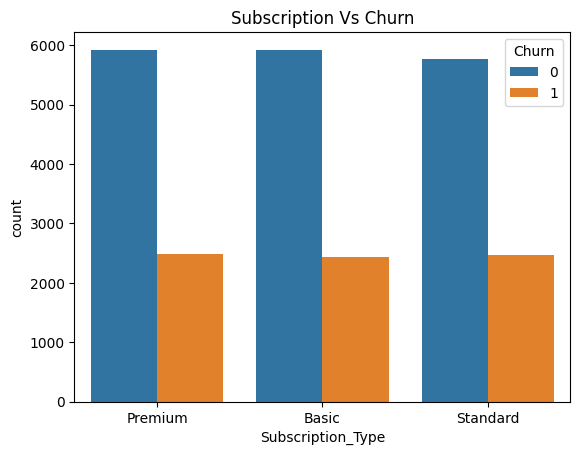

In [16]:
sns.countplot(x='Subscription_Type', hue='Churn', data=df)
plt.title('Subscription Vs Churn')
plt.show()

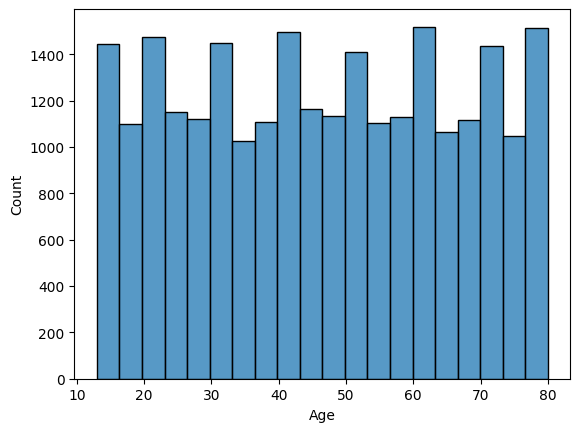

In [17]:
sns.histplot(df['Age'],bins=20)
plt.show()

<h3>Feature Scaling</h3>

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

<h3>Encoding categorical features</h3>
Model need numbers

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [20]:
df['Favorite_Genre'] = le.fit_transform(df['Favorite_Genre'])

In [21]:
df['Country'] = le.fit_transform(df['Country'])
df['Subscription_Type'] = le.fit_transform(df['Subscription_Type'])

In [22]:
df.head(2)

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Churn
0,18,3,1,80.26,3,1
1,23,9,1,321.75,6,0


<h3>Split data</h3>

In [23]:
X = df.drop("Churn" , axis=1)
y = df["Churn"]

<h3>Train test</h3>

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

<h3>Train Machine Learning Model</h3>

In [27]:
# random forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(max_depth=5)
model.fit(X_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

<h3>ModelPrediction</h3>

In [28]:
y_pred = model.predict(X_test_scaled)

<h3>Accuracy Score test</h3>

In [29]:
from sklearn.metrics  import accuracy_score, classification_report

In [30]:
accuracy_score(y_test,y_pred)

0.996

In [31]:
print("Accuracy:", model.score(X_test_scaled, y_test))


Accuracy: 0.996


In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3511
           1       1.00      0.99      0.99      1489

    accuracy                           1.00      5000
   macro avg       1.00      0.99      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [33]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[3511    0]
 [  20 1469]]


In [34]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.99      1.00      1.00      3511\n           1       1.00      0.99      0.99      1489\n\n    accuracy                           1.00      5000\n   macro avg       1.00      0.99      1.00      5000\nweighted avg       1.00      1.00      1.00      5000\n'

In [36]:
df.head(2)

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Churn
0,18,3,1,80.26,3,1
1,23,9,1,321.75,6,0


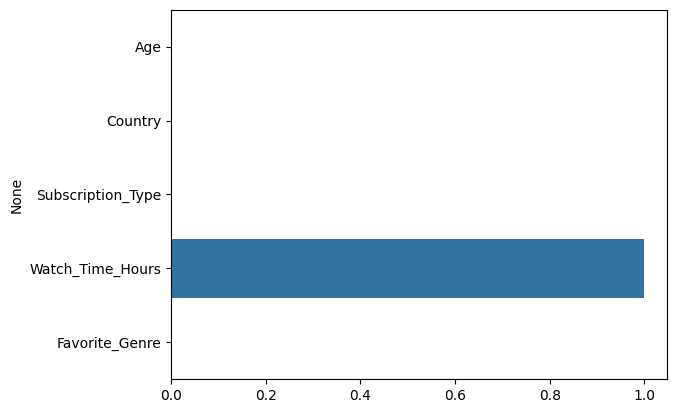

In [39]:
importances = model.feature_importances_
features = X.columns
sns.barplot(x=importances,y=features)
plt.show()


<h3>Saving model</h3>

In [41]:
import pickle
pickle.dump(model,open("churn_model.pkl","wb"))